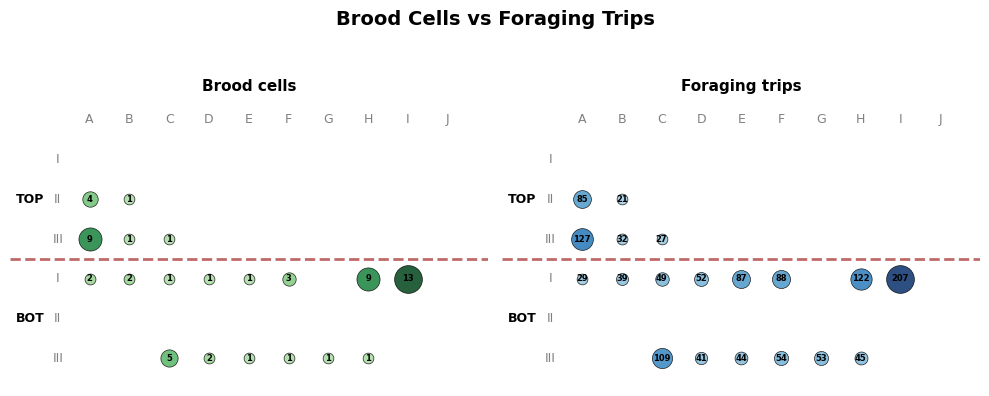

Release 1: 19 active tubes
Release 1: 59 total brood cells
Release 1: 1311 total foraging trips


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# LOAD DATA
# -----------------------------
raw = pd.read_csv("data/nesting_data.csv")
events = pd.read_csv("data/aggregated_events.csv")

# -----------------------------
# MAP NEST CODE -> TUBE NUMBER
# -----------------------------
frame_offset = {'MT': 0, 'NT': 0, 'MB': 30, 'NB': 30}
row_offset = {'I': 0, 'II': 10, 'III': 20}
letter_pos = {chr(65 + i): i + 1 for i in range(10)}

raw['row'] = raw['nest_code'].str.split('-').str[0]
raw['letter'] = raw['nest_code'].str.split('-').str[1]
raw['tube_num'] = raw.apply(
    lambda r: frame_offset.get(r['frame_id'], 0)
    + row_offset.get(r['row'], 0)
    + letter_pos.get(r['letter'], 0),
    axis=1
)

# -----------------------------
# FILTER TO MENDELS, RELEASE 1
# -----------------------------
raw_m = raw[raw['site'] == 'Mendels'].copy()
raw_r1 = raw_m[raw_m['release'] == 1].copy()

r1_tubes = np.sort(raw_r1['tube_num'].dropna().unique())

# brood cells per tube
r1_cells = raw_r1.groupby('tube_num').size()

# -----------------------------
# PREP EVENTS
# -----------------------------
events['event_datetime'] = pd.to_datetime(events['event_datetime'])
events_m = events[events['site'] == 'mendels'].copy()
events_m = events_m.sort_values(['nest', 'event_datetime'])

# -----------------------------
# BUILD TRIPS FROM EVENTS
# -----------------------------
trips = []

for nest, grp in events_m.groupby('nest'):
    grp = grp.sort_values('event_datetime').reset_index(drop=True)
    i = 0
    while i < len(grp) - 1:
        if grp.loc[i, 'action'] == 'Exit':
            for j in range(i + 1, len(grp)):
                if grp.loc[j, 'action'] == 'Entry':
                    exit_time = grp.loc[i, 'event_datetime']
                    entry_time = grp.loc[j, 'event_datetime']
                    duration = (entry_time - exit_time).total_seconds() / 60.0
                    trips.append({
                        'nest': nest,
                        'exit_time': exit_time,
                        'entry_time': entry_time,
                        'duration_min': duration
                    })
                    i = j + 1
                    break
            else:
                i += 1
        else:
            i += 1

trips_df = pd.DataFrame(trips)

# -----------------------------
# FILTER TO PLAUSIBLE TRIPS
# -----------------------------
trips_clean = trips_df[
    (trips_df['duration_min'] > 0.5) &
    (trips_df['duration_min'] < 30) &
    (trips_df['exit_time'].dt.hour.between(6, 20))
].copy()

# -----------------------------
# FILTER TO RELEASE 1 WINDOW
# -----------------------------
r1_trips = trips_clean[
    (trips_clean['exit_time'] >= '2024-04-16') &
    (trips_clean['exit_time'] < '2024-05-16')
].copy()

# trips per nest, only for release 1 tubes
r1_trip_counts = (
    r1_trips[r1_trips['nest'].isin(r1_tubes)]
    .groupby('nest')
    .size()
)

# -----------------------------
# PLOTTING HELPERS
# -----------------------------
def tube_to_grid(tube_num):
    grid_row = (tube_num - 1) // 10
    grid_col = (tube_num - 1) % 10
    return grid_row, grid_col

def draw_hotel(ax, tubes, counts, title, cmap_name='Greens'):
    max_val = counts.max() if len(counts) > 0 and counts.max() > 0 else 1
    cmap = plt.colormaps[cmap_name]

    for tube_num in tubes:
        grow, gcol = tube_to_grid(tube_num)
        y = 5 - grow
        val = counts.get(tube_num, 0)

        if val == 0:
            ax.scatter(
                gcol, y, s=60, c='#eeeeee',
                edgecolors='#cccccc', linewidths=0.5, zorder=2
            )
            continue

        norm_val = val / max_val
        size = max(norm_val * 400, 60)

        ax.scatter(
            gcol, y,
            s=size,
            c=[cmap(0.3 + norm_val * 0.7)],
            edgecolors='k',
            linewidths=0.5,
            alpha=0.85,
            zorder=2
        )
        ax.text(
            gcol, y, str(val),
            ha='center', va='center',
            fontsize=6, fontweight='bold', zorder=3
        )

    # divider between top and bottom frames
    ax.axhline(y=2.5, color='brown', linewidth=2, linestyle='--', alpha=0.7)

    for r, lbl in [(5, 'I'), (4, 'II'), (3, 'III'), (2, 'I'), (1, 'II'), (0, 'III')]:
        ax.text(-0.8, r, lbl, ha='center', va='center', fontsize=9, color='gray')

    for c in range(10):
        ax.text(c, 6.0, chr(65 + c), ha='center', va='center', fontsize=9, color='gray')

    ax.text(-1.5, 4.0, 'TOP', ha='center', va='center', fontsize=9, fontweight='bold')
    ax.text(-1.5, 1.0, 'BOT', ha='center', va='center', fontsize=9, fontweight='bold')

    ax.set_xlim(-2, 10)
    ax.set_ylim(-0.7, 6.5)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=11, fontweight='bold')

# -----------------------------
# FIGURE: RELEASE 1 ONLY
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
fig.suptitle('Brood Cells vs Foraging Trips', fontsize=14, fontweight='bold')

draw_hotel(
    axes[0],
    r1_tubes,
    r1_cells,
    'Brood cells',
    'Greens'
)

draw_hotel(
    axes[1],
    r1_tubes,
    r1_trip_counts,
    'Foraging trips',
    'Blues'
)

plt.tight_layout()
#plt.savefig('mendels_release1_cells_vs_trips.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Release 1: {len(r1_tubes)} active tubes")
print(f"Release 1: {r1_cells.sum()} total brood cells")
print(f"Release 1: {r1_trip_counts.sum()} total foraging trips")

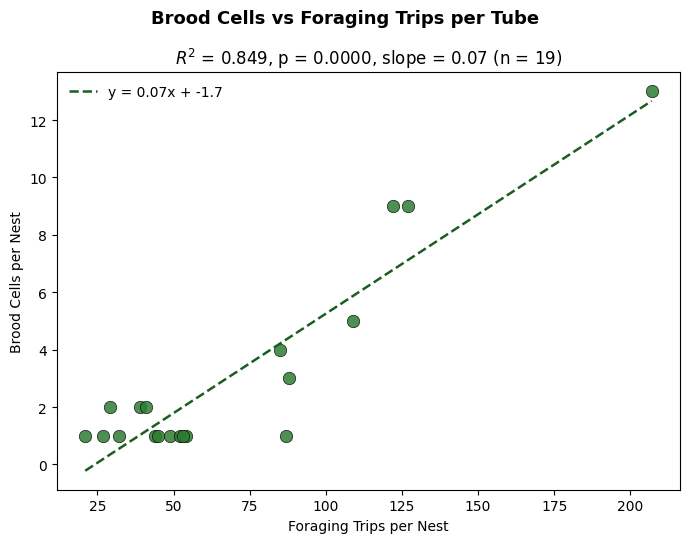

Release 1 (n = 19):
  slope = 0.069 cells/trip (±0.007)
  intercept = -1.68
  R² = 0.849
  p = 0.0000


In [20]:
from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def build_compare(tubes, cells, trips):
    tubes_sorted = sorted(tubes)
    return pd.DataFrame({
        'tube': tubes_sorted,
        'cells': [cells.get(t, 0) for t in tubes_sorted],
        'trips': [trips.get(t, 0) for t in tubes_sorted]
    })

# Release 1 only
r1_df = build_compare(r1_tubes, r1_cells, r1_trip_counts)

# Linear regression
slope, intercept, r_val, p_val, std_err = stats.linregress(
    r1_df['trips'], r1_df['cells']
)

# Line for plotting
x_line = np.linspace(r1_df['trips'].min(), r1_df['trips'].max(), 100)
y_line = slope * x_line + intercept

# Plot
fig, ax = plt.subplots(figsize=(7, 5.5))
fig.suptitle(
    'Brood Cells vs Foraging Trips per Tube',
    fontsize=13,
    fontweight='bold'
)

# Scatter (clean)
ax.scatter(
    r1_df['trips'],
    r1_df['cells'],
    s=80,
    c='#2E7D32',
    edgecolors='k',
    linewidths=0.5,
    alpha=0.85
)

# Regression line
ax.plot(
    x_line,
    y_line,
    '--',
    color='#1B5E20',
    linewidth=1.8,
    label=f'y = {slope:.2f}x + {intercept:.1f}'
)

# Labels
ax.set_xlabel('Foraging Trips per Nest')
ax.set_ylabel('Brood Cells per Nest')

# Metrics in title (clean and reviewer-friendly)
ax.set_title(
    f'$R^2$ = {r_val**2:.3f}, p = {p_val:.4f}, slope = {slope:.2f} (n = {len(r1_df)})'
)

ax.legend(frameon=False)

plt.tight_layout()
#plt.savefig('mendels_release1_linear_regression_clean.png', dpi=150, bbox_inches='tight')
plt.show()

# Print stats
print(f"Release 1 (n = {len(r1_df)}):")
print(f"  slope = {slope:.3f} cells/trip (±{std_err:.3f})")
print(f"  intercept = {intercept:.2f}")
print(f"  R² = {r_val**2:.3f}")
print(f"  p = {p_val:.4f}")

Release 1 bins: 5219
Active: 980 (18.8%)
Fold 1: AUC = 0.699
Fold 2: AUC = 0.838
Fold 3: AUC = 0.875
Fold 4: AUC = 0.886
Fold 5: AUC = 0.859

Mean AUC: 0.832 ± 0.068


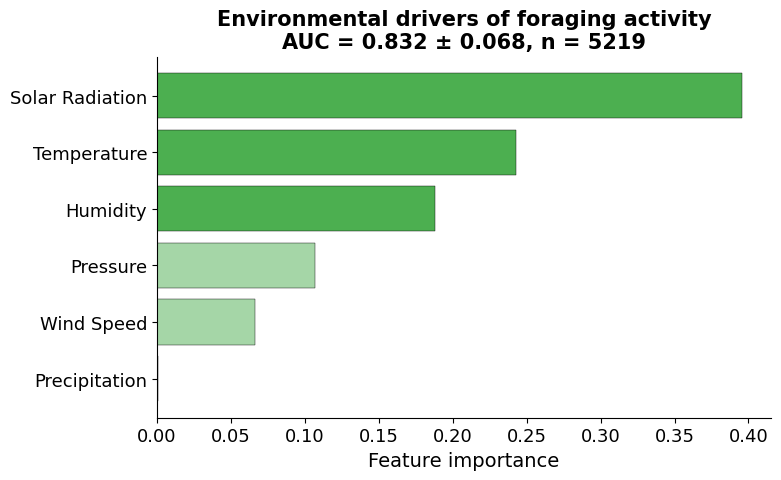

In [25]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

# -----------------------------
# RELEASE 1 WINDOW
# -----------------------------
start_date = pd.Timestamp("2024-04-16")
end_date = pd.Timestamp("2024-05-15 23:59:59")

# -----------------------------
# LOAD WEATHER
# -----------------------------
weather = pd.read_csv(
    'data/weather_5min.csv',
    parse_dates=['datetime'],
    index_col='datetime'
)

weather = weather.drop(columns=['wind_dir', 'uv'], errors='ignore')  # 🔥 remove UV here
weather.index = weather.index.floor('5min')
weather = weather.groupby(level=0).mean(numeric_only=True)

# Restrict to Release 1
weather = weather[(weather.index >= start_date) & (weather.index <= end_date)].copy()

# -----------------------------
# LOAD FORAGING TRIPS
# -----------------------------
trips = pd.read_csv('data/foraging_trips.csv', parse_dates=['exit_time'])

trips = trips[(trips['exit_time'] >= start_date) & (trips['exit_time'] <= end_date)].copy()

# Bin trips
trips['time_bin'] = trips['exit_time'].dt.floor('5min')
trip_counts = trips.groupby('time_bin').size().rename('trips')

# -----------------------------
# MERGE
# -----------------------------
merged = weather.join(trip_counts, how='left')
merged['trips'] = merged['trips'].fillna(0).astype(int)

# Daytime filter
merged = merged[(merged.index.hour >= 6) & (merged.index.hour <= 20)].copy()

# Binary activity
merged['active'] = (merged['trips'] > 0).astype(int)

# -----------------------------
# FEATURES (UV removed)
# -----------------------------
features = [
    'temperature', 'humidity', 'speed',
    'pressure', 'precip_rate', 'solar'
]

label_map = {
    'temperature': 'Temperature',
    'humidity': 'Humidity',
    'speed': 'Wind Speed',
    'pressure': 'Pressure',
    'precip_rate': 'Precipitation',
    'solar': 'Solar Radiation'
}

df = merged[features + ['active']].dropna().copy()
X = df[features]
y = df['active']

print(f"Release 1 bins: {len(df)}")
print(f"Active: {y.sum()} ({y.mean()*100:.1f}%)")

# -----------------------------
# TIME SERIES CV
# -----------------------------
tscv = TimeSeriesSplit(n_splits=5)

all_y_true, all_y_prob = [], []
fold_aucs = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    rf = RandomForestClassifier(
        n_estimators=500,
        max_depth=8,
        min_samples_leaf=10,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X.iloc[train_idx], y.iloc[train_idx])
    y_prob = rf.predict_proba(X.iloc[test_idx])[:, 1]

    fold_auc = roc_auc_score(y.iloc[test_idx], y_prob)
    fold_aucs.append(fold_auc)

    all_y_true.extend(y.iloc[test_idx])
    all_y_prob.extend(y_prob)

    print(f"Fold {fold+1}: AUC = {fold_auc:.3f}")

mean_auc = np.mean(fold_aucs)
std_auc = np.std(fold_aucs)

print(f"\nMean AUC: {mean_auc:.3f} ± {std_auc:.3f}")

# -----------------------------
# FINAL MODEL
# -----------------------------
rf_final = RandomForestClassifier(
    n_estimators=500,
    max_depth=8,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_final.fit(X, y)

# -----------------------------
# FEATURE IMPORTANCE FIGURE
# -----------------------------
plt.rcParams.update({
    "font.size": 13,
    "axes.titlesize": 15,
    "axes.labelsize": 14
})

fig, ax = plt.subplots(figsize=(8, 5))

importances = pd.Series(rf_final.feature_importances_, index=features).sort_values()
labels = [label_map[f] for f in importances.index]

colors = ['#4CAF50' if v > importances.median() else '#A5D6A7' for v in importances.values]

ax.barh(labels, importances.values, color=colors, edgecolor='k', linewidth=0.3)

ax.set_xlabel('Feature importance')
ax.set_title(
    f'Environmental drivers of foraging activity\n'
    f'AUC = {mean_auc:.3f} ± {std_auc:.3f}, n = {len(df)}',
    fontweight='bold'
)

ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('rf_feature_importance_release1_clean.png', dpi=300, bbox_inches='tight')
plt.show()